In [7]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define paths relative to the script location
data_dir = '../datafile'

In [15]:
def analyze_json_files(directory):
    total_all_years = 0
    category_totals = {}

    print(f"{'Year':<10} | {'Category':<30} | {'Questions':<10}")
    print("-" * 55)

    # Sorting the listdir ensures years appear in order (e.g., 2020, 2021...)
    for filename in sorted(os.listdir(directory)):
        if filename.endswith('.json'):
            year = filename.replace('.json', '')
            filepath = os.path.join(directory, filename)
            
            with open(filepath, 'r') as f:
                try:
                    data = json.load(f)
                    root = data.get('root', data)
                    
                    year_total = 0
                    
                    for category, content in root.items():
                        # Count keys that start with 'question_'
                        q_count = len([k for k in content.keys() if k.startswith('question_')])
                        
                        year_total += q_count
                        category_totals[category] = category_totals.get(category, 0) + q_count
                        
                        print(f"{year:<10} | {category:<30} | {q_count:<10}")
                    
                    # --- NEW: Print the total for the specific year ---
                    print(f"{'':<10} | {'YEAR TOTAL':<30} | **{year_total}**")
                    print("-" * 55)
                    
                    total_all_years += year_total
                
                except Exception as e:
                    print(f"Error reading {filename}: {e}")

    # Final summary
    print("\n### GRAND TOTALS ACROSS ALL YEARS ###")
    for cat, count in sorted(category_totals.items()):
        print(f"{cat:<30}: {count}")
    
    print("-" * 35)
    print(f"{'OVERALL TOTAL QUESTIONS':<30}: {total_all_years}")

def plot(directory):
    # We will store data in a list of dicts to create a DataFrame easily
    data_records = []
    
    for filename in sorted(os.listdir(directory)):
        if filename.endswith('.json'):
            year = filename.replace('.json', '')
            filepath = os.path.join(directory, filename)
            
            with open(filepath, 'r') as f:
                try:
                    data = json.load(f)
                    root = data.get('root', data)
                    
                    for category, content in root.items():
                        q_count = len([k for k in content.keys() if k.startswith('question_')])
                        
                        # Save to list for the graph
                        data_records.append({
                            'Year': year,
                            'Category': category,
                            'QuestionCount': q_count
                        })
                except Exception as e:
                    print(f"Error reading {filename}: {e}")

    # Create DataFrame
    df = pd.DataFrame(data_records)
    
    if df.empty:
        print("No data found to plot.")
        return

    # --- PLOTTING ---
    
    # 1. Prepare data for a stacked bar chart
    # Pivot the data so Years are the index and Categories are columns
    pivot_df = df.pivot(index='Year', columns='Category', values='QuestionCount').fillna(0)

    # 2. Create the plot
    ax = pivot_df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

    # Add labels and styling
    plt.title('Question Distribution per Category by Year', fontsize=14, pad=15)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Questions', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    plt.close()

In [16]:
if __name__ == "__main__":
    analyze_json_files(data_dir)

Year       | Category                       | Questions 
-------------------------------------------------------
2011       | freshman_sophomore_test        | 18        
2011       | junior_senior_test             | 19        
           | YEAR TOTAL                     | **37**
-------------------------------------------------------
2012       | freshman_sophomore_test        | 20        
2012       | junior_senior_test             | 20        
2012       | two_person_speed_event         | 10        
           | YEAR TOTAL                     | **50**
-------------------------------------------------------
2013       | freshman_sophomore_test        | 17        
2013       | junior_senior_test             | 18        
2013       | two_person_speed_event         | 10        
           | YEAR TOTAL                     | **45**
-------------------------------------------------------
2014       | freshman_sophomore_test        | 18        
2014       | junior_senior_test             | 1

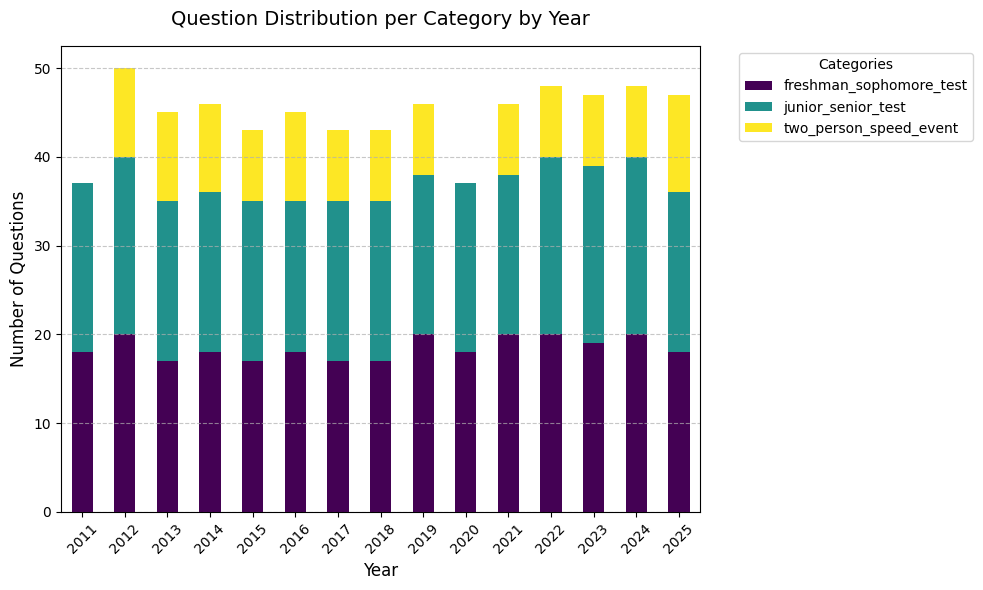

In [17]:
plot(data_dir)